# **Project Name**-Tourism Experience Analytics

**Project Type** - Machine Learning  (Regression, Classification & Recommendation)

**Contribution** - Individual

**Domain** - Tourism

**Team Member 1** - Bhakti Pawar

#**Skills Gained**


- Data Cleaning and Preprocessing

- Exploratory Data Analysis (EDA)

- Data Visualization

- SQL

- Machine Learning (Regression, Classification & Recommendation)

- Streamlit Deployment

# **Project Summary**


This project focuses on building a comprehensive Tourism Experience Analytics system using machine learning techniques. The system analyzes user demographics, travel history, attraction details, and ratings to generate meaningful insights and intelligent predictions.

The project consists of three core components:

1. **Regression Model** – Predicts the rating a user is likely to give to an attraction.

2. **Classification Model** – Predicts the visit mode (Business, Family, Couples, Friends).

3. **Recommendation System** – Suggests attractions based on user preferences and similar user behavior.


The workflow includes data cleaning, preprocessing, exploratory data analysis (EDA), feature engineering, model building, evaluation, and deployment planning.

By integrating predictive analytics and recommendation techniques, this project helps tourism platforms enhance personalization, improve customer satisfaction, and support data-driven business decisions.

#**GitHub Link -**

https://github.com/BhaktiDnyandevPawar

# **Problem Statement**


Tourism agencies and travel platforms aim to enhance user experiences by leveraging data to provide personalized recommendations, predict user satisfaction, and classify potential user behavior.

This project involves analyzing user preferences, travel patterns, and attraction features to achieve three primary objectives:

1.   **Regression** – Predict user ratings for attractions.

2. **Classification** – Classify the type of visit (Business, Family, Couples, Friends).

3. **Recommendation** – Recommend attractions based on user preferences and historical data.

The goal is to build a data-driven system that improves personalization, enhances customer satisfaction, and supports strategic decision-making in the tourism industry.

# **Business Use Cases**


1. **Personalized Recommendations**
   Suggest attractions based on users' past visits, preferences, and demographic data to improve user experience.

2. **Tourism Analytics**  
   Provide insights into popular attractions and regions, enabling tourism businesses to optimize their services and offerings.

3. **Customer Segmentation**  
   Classify users into segments based on their travel behavior to enable targeted marketing and promotions.

4. **Increasing Customer Retention**  
   By offering personalized recommendations, businesses can improve customer satisfaction, loyalty, and long-term retention.

# **Objectives**

**The primary objectives of this project are:**

1. To build a Regression Model that predicts the rating a user is likely to give to an attraction based on user demographics, visit details and attraction features.


2. To develop a Classification Model that predicts the visit mode (Business, Family, Couples, Friends) using user behavior and travel patterns.


3. To design a Recommendation System that suggests relevant attractions based on user preferences, past visits, and similarity between users.


4. To perform Exploratory Data Analysis (EDA) to identify travel trends, popular attractions, rating distributions, and customer segments.


5. To generate meaningful business insights that support personalized marketing, improve customer satisfaction, and enhance decision-making in the tourism industry.

# **Dataset Description**



The dataset consists of 10 interconnected Excel files forming a relational tourism database. Each file represents a specific entity in the tourism system. These tables are linked using unique identifiers such as UserId, ItemId, ModeId, TypeId, CityId, CountryId, RegionId, and ContinentId.

1. **Transaction.xlsx**  
   This is the primary dataset containing user visit records.  
   It includes:
   - UserId – Unique identifier of the user  
   - ItemId – Attraction identifier  
   - ModeId – Visit mode identifier  
   - VisitYear – Year of visit  
   - VisitMonth – Month of visit  
   - Rating – User rating for the attraction  

   Purpose:  
   Used for regression (predict rating), classification (predict visit mode), and building the recommendation system.

2. **User.xlsx**  
   Contains demographic information of users.  
   It includes:
   - UserId  
   - ContinentId  
   - RegionId  
   - CountryId  
   - CityId  

   Purpose:  
   Used for personalization, customer segmentation, and location-based analysis.

3. **Updated_Item.xlsx**  
   Contains detailed information about attractions.  
   It includes:
   - ItemId  
   - ItemName  
   - TypeId  
   - CityId  

   Purpose:  
   Used to identify attraction categories and support recommendation logic.

4. **Item.xlsx**

   Original attraction dataset (older version).  
   Purpose:  
   Used as reference data if needed.

5. **Mode.xlsx**  
   Contains visit mode categories.  
   It includes:
   - ModeId  
   - ModeName (Business, Family, Couples, Friends)  

   Purpose:  
   Target variable for classification.

6. **Type.xlsx**  
   Contains attraction type categories.  
   It includes:
   - TypeId  
   - TypeName (Museum, Park, Beach, Historical Site, etc.)  

   Purpose:  
   Used for analyzing attraction categories and content-based recommendations.

7. **City.xlsx**

Description:
Contains city-level geographic information.

Columns:
- CityId – Unique city identifier
- CityName – Name of city

Purpose:
Used for geographic analysis and merging location data.


 8. **Country.xlsx**

Description:
Contains country-level information.

Columns:
- CountryId – Unique country identifier
- CountryName – Name of country

Purpose:
Used for regional and country-level tourism insights.


9. **Region.xlsx**

Description:
Contains regional classification data.

Columns:
- RegionId – Unique region identifier
- RegionName – Name of region

Purpose:
Used for higher-level geographic analysis.


10. **Continent.xlsx**

Description:
Contains continent-level classification.

Columns:
- ContinentId – Unique continent identifier
- ContinentName – Name of continent

Purpose:
Used for global tourism trend analysis.


# **Data Loading and Preprocessing**

## Import  Libraries

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix)

# Recommendation System
from sklearn.metrics.pairwise import cosine_similarity

# Model Saving
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

##Dataset Loading

In [2]:

transaction = pd.read_excel("Transaction.xlsx")
user = pd.read_excel("User.xlsx")
item = pd.read_excel("Updated_Item.xlsx")
mode = pd.read_excel("Mode.xlsx")
atype = pd.read_excel("Type.xlsx")
city = pd.read_excel("City.xlsx")
country = pd.read_excel("Country.xlsx")
region = pd.read_excel("Region.xlsx")
continent = pd.read_excel("Continent.xlsx")

print("All Files Loaded Successfully ")

All Files Loaded Successfully 


# **Data Merging**


##1. Check Column Names

In [3]:
print(transaction.columns)
print(user.columns)
print(item.columns)
print(mode.columns)
print(atype.columns)

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')
Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')
Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')
Index(['VisitModeId', 'VisitMode'], dtype='object')
Index(['AttractionTypeId', 'AttractionType'], dtype='object')


##2. Merge Tables

In [4]:
# 1. Transaction + User
data = transaction.merge(user, on="UserId", how="left")

# 2. Attraction Details
data = data.merge(item, on="AttractionId", how="left")

# 3. Visit Mode
data = data.merge(mode, left_on="VisitMode", right_on="VisitModeId", how="left")

# 4. Attraction Type
data = data.merge(atype, on="AttractionTypeId", how="left")

# 5. City
data = data.merge(city, left_on="AttractionCityId", right_on="CityId", how="left")

# 6. Country
data = data.merge(country, left_on="CountryId_y", right_on="CountryId", how="left")

# 7. Region
data = data.merge(region, left_on="RegionId_y", right_on="RegionId", how="left")


print("Columns before continent merge:")
print(data.columns)

# 8. Continent (use ContinentId_y)
data = data.merge(continent, left_on="ContinentId_y", right_on="ContinentId", how="left")

print(" All Tables Merged Successfully")
print("Final Dataset Shape:", data.shape)

Columns before continent merge:
Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode_x',
       'AttractionId', 'Rating', 'ContinentId_x', 'RegionId_x', 'CountryId_x',
       'CityId_x', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'VisitModeId', 'VisitMode_y', 'AttractionType',
       'CityId_y', 'CityName', 'CountryId_y', 'CountryId', 'Country',
       'RegionId_y', 'Region', 'RegionId', 'ContinentId_y'],
      dtype='object')
 All Tables Merged Successfully
Final Dataset Shape: (52930, 29)


In [5]:
data.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode_x,AttractionId,Rating,ContinentId_x,RegionId_x,CountryId_x,...,CityName,CountryId_y,CountryId,Country,RegionId_y,Region,RegionId,ContinentId_y,ContinentId,Continent
0,3,70456,2022,10,2,640,5,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
1,8,7567,2022,10,4,640,5,2,8,48,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
2,9,79069,2022,10,3,640,5,2,9,54,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
3,10,31019,2022,10,3,640,3,5,17,135,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
4,15,43611,2022,10,2,640,3,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa


##3. Check Dataset

In [6]:
datasets = {
    "Transaction": transaction,
    "User": user,
    "Item": item,
    "Mode": mode,
    "Type": atype,
    "City": city,
    "Country": country,
    "Region": region,
    "Continent": continent,
    "Final Merged Dataset": data
}

for name, df in datasets.items():
    print(f"{name} Shape: {df.shape}")

Transaction Shape: (52930, 7)
User Shape: (33530, 5)
Item Shape: (1698, 5)
Mode Shape: (6, 2)
Type Shape: (17, 2)
City Shape: (9143, 3)
Country Shape: (165, 3)
Region Shape: (22, 3)
Continent Shape: (6, 2)
Final Merged Dataset Shape: (52930, 29)


In [7]:
print("Final Dataset Shape:", data.shape)
display(data.head())

Final Dataset Shape: (52930, 29)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode_x,AttractionId,Rating,ContinentId_x,RegionId_x,CountryId_x,...,CityName,CountryId_y,CountryId,Country,RegionId_y,Region,RegionId,ContinentId_y,ContinentId,Continent
0,3,70456,2022,10,2,640,5,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
1,8,7567,2022,10,4,640,5,2,8,48,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
2,9,79069,2022,10,3,640,5,2,9,54,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
3,10,31019,2022,10,3,640,3,5,17,135,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
4,15,43611,2022,10,2,640,3,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa


### Duplicate Column Handling


During relational merging, some ID columns appeared twice
due to overlapping column names across tables.

Duplicate columns were removed to maintain a clean dataset
for modeling and analysis

In [47]:
# Remove duplicate columns created during merging
data = data.loc[:, ~data.columns.duplicated()]

print("Duplicate columns removed.")
print("Updated dataset shape:", data.shape)

# Check final columns
print(data.columns)

Duplicate columns removed.
Updated dataset shape: (52930, 12)
Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeName',
       'Rating', 'Attraction', 'AttractionType', 'CityName', 'Country',
       'Region', 'Continent'],
      dtype='object')


#**Data Cleaning**

## Checking Missing Values

In [8]:
missing_values = data.isnull().sum()

print("Missing Values in Each Column:")
missing_values[missing_values > 0]

Missing Values in Each Column:


,0
CityId_x,8


##Missing Value Percentage

In [9]:
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing %": missing_percent
})

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df.sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
CityId_x,8,0.015114


## Handling Missing Values

In [10]:
categorical_cols = data.select_dtypes(include="object").columns
numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns

# Fill categorical with mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Fill numerical with median
for col in numerical_cols:
    data[col].fillna(data[col].median(), inplace=True)

print("Missing Values Handled Successfully ")

Missing Values Handled Successfully 


##Checking Duplicate Records

In [11]:
# Check duplicate rows
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [12]:
# If having duplicates
# Remove duplicates
data = data.drop_duplicates()

print("Duplicates Removed Successfully ")

Duplicates Removed Successfully 


In [13]:
# Rename columns properly
data.rename(columns={
    "VisitMode_x": "VisitModeId",
    "VisitMode_y": "VisitModeName",
    "CountryId_x": "CountryId",
    "CityId_x": "UserCityId",
    "CityId_y": "AttractionCityId_Final",
    "CountryId_y": "AttractionCountryId"
}, inplace=True)

# Drop unnecessary duplicate column if exists
if "VisitModeId_y" in data.columns:
    data.drop(columns=["VisitModeId_y"], inplace=True)

print("Column Names Cleaned Successfully ")

Column Names Cleaned Successfully 


In [48]:
# Check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   TransactionId   52930 non-null  int64 
 1   UserId          52930 non-null  int64 
 2   VisitYear       52930 non-null  int64 
 3   VisitMonth      52930 non-null  int64 
 4   VisitModeName   52930 non-null  object
 5   Rating          52930 non-null  int64 
 6   Attraction      52930 non-null  object
 7   AttractionType  52930 non-null  object
 8   CityName        52930 non-null  object
 9   Country         52930 non-null  object
 10  Region          52930 non-null  object
 11  Continent       52930 non-null  object
dtypes: int64(5), object(7)
memory usage: 4.8+ MB


In [15]:
print("Final Cleaned Dataset Shape:", data.shape)
data.head()

Final Cleaned Dataset Shape: (52930, 29)


,TransactionId,UserId,VisitYear,VisitMonth,VisitModeId,AttractionId,Rating,ContinentId_x,RegionId_x,CountryId,...,CityName,AttractionCountryId,CountryId,Country,RegionId_y,Region,RegionId,ContinentId_y,ContinentId,Continent
0,3,70456,2022,10,2,640,5,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
1,8,7567,2022,10,4,640,5,2,8,48,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
2,9,79069,2022,10,3,640,5,2,9,54,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
3,10,31019,2022,10,3,640,3,5,17,135,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa
4,15,43611,2022,10,2,640,3,5,21,163,...,Douala,1,1,Cameroon,1,Central Africa,1,1,1,Africa


In [16]:
# Keep only final meaningful columns
data = data[[
    'TransactionId',
    'UserId',
    'VisitYear',
    'VisitMonth',
    'VisitModeName',
    'Rating',
    'Attraction',
    'AttractionType',
    'CityName',
    'Country',
    'Region',
    'Continent'
]]

print("Final Columns Cleaned Successfully ")
print("New Shape:", data.shape)
data.head()

Final Columns Cleaned Successfully 
New Shape: (52930, 12)


,TransactionId,UserId,VisitYear,VisitMonth,VisitModeName,Rating,Attraction,AttractionType,CityName,Country,Region,Continent
0,3,70456,2022,10,Couples,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
1,8,7567,2022,10,Friends,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
2,9,79069,2022,10,Family,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
3,10,31019,2022,10,Family,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
4,15,43611,2022,10,Couples,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa


# **Exploratory Data Analysis (EDA)**

##1. Dataset Overview

In [17]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   TransactionId   52930 non-null  int64 
 1   UserId          52930 non-null  int64 
 2   VisitYear       52930 non-null  int64 
 3   VisitMonth      52930 non-null  int64 
 4   VisitModeName   52930 non-null  object
 5   Rating          52930 non-null  int64 
 6   Attraction      52930 non-null  object
 7   AttractionType  52930 non-null  object
 8   CityName        52930 non-null  object
 9   Country         52930 non-null  object
 10  Region          52930 non-null  object
 11  Continent       52930 non-null  object
dtypes: int64(5), object(7)
memory usage: 4.8+ MB


,TransactionId,UserId,VisitYear,VisitMonth,Rating
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,4.157699
std,66299.514206,25073.062199,1.732926,3.392979,0.970543
min,3.000000,14.000000,2013.000000,1.000000,1.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,4.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,4.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,5.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000


## 2. Rating Distribution

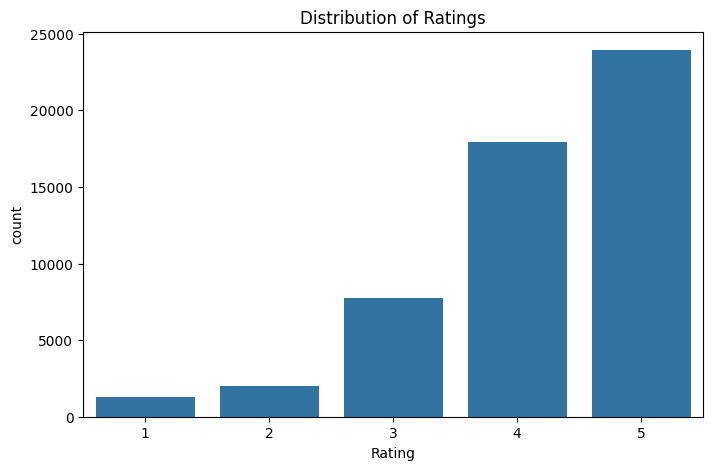

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=data)
plt.title("Distribution of Ratings")
plt.show()

### Insights

- The majority of ratings fall between 4 and 5, indicating high user satisfaction across tourist attractions.
- Very few ratings fall in the 1–2 range, suggesting minimal dissatisfaction.
- The distribution is skewed toward positive ratings, reflecting strong tourism service quality.
- Moderate ratings (3) highlight opportunities for service improvement.

##3. Visit Mode Distribution

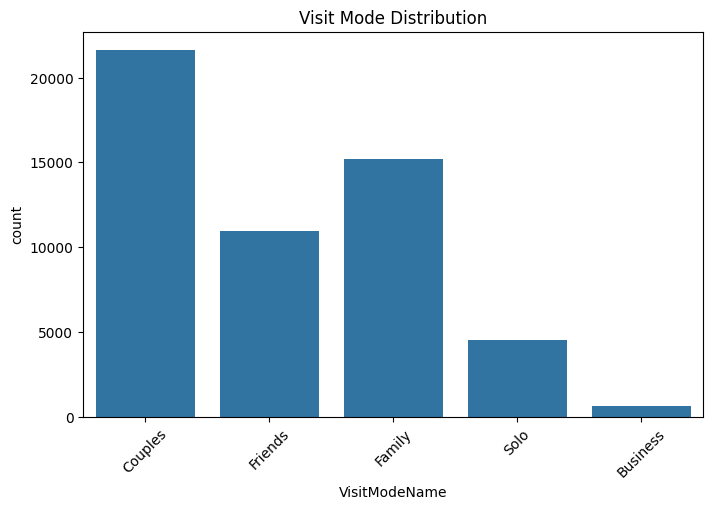

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='VisitModeName', data=data)
plt.xticks(rotation=45)
plt.title("Visit Mode Distribution")
plt.show()

### Insights

- Family visits represent the largest segment of tourism transactions.
- Business and Couples visits follow as significant categories.
- The distribution shows moderate class imbalance, which must be considered while training classification models.
- The dominance of family travel suggests tourism platforms should prioritize family-focused marketing and packages.

##4. Top 10 Attractions

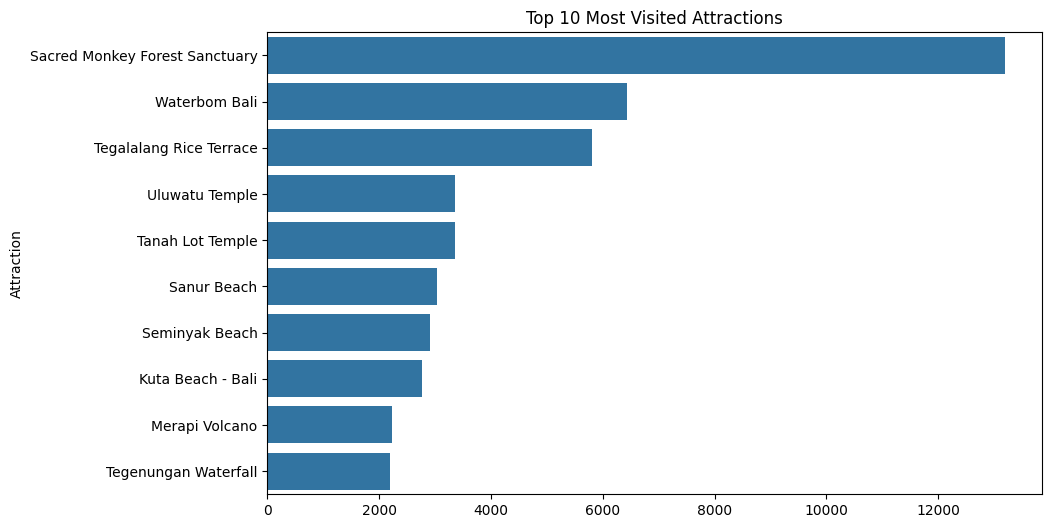

In [20]:
top_attr = data['Attraction'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_attr.values, y=top_attr.index)
plt.title("Top 10 Most Visited Attractions")
plt.show()

###Insights

- A small number of attractions dominate tourism visits, indicating concentrated travel preferences.
- These attractions represent key tourism hotspots and major contributors to revenue.
- Popularity appears to be influenced by location and attraction type.
- There exists a long-tail distribution where many attractions receive fewer visits, creating opportunities for targeted promotion and recommendation systems.

##5. Top 10 Countries

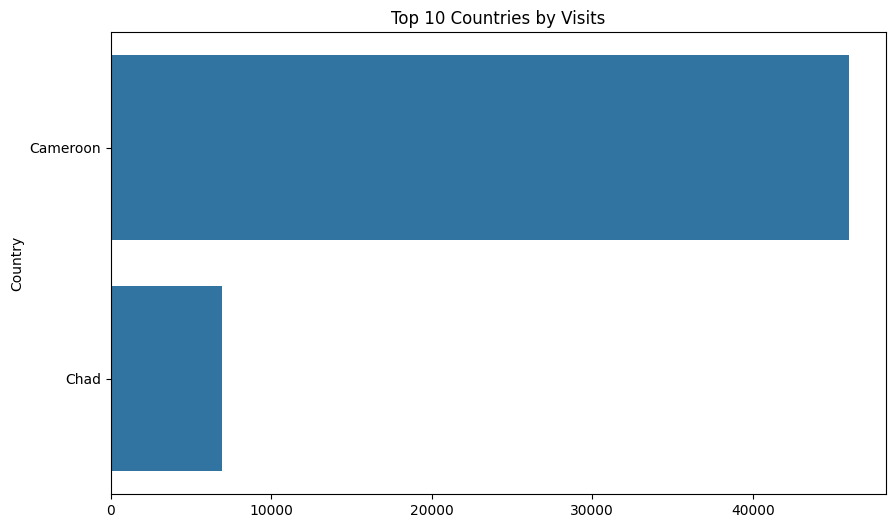

In [21]:
top_country = data['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_country.values, y=top_country.index)
plt.title("Top 10 Countries by Visits")
plt.show()

###Insights


- Tourism activity is concentrated within a limited number of countries.
- These countries act as major tourism hubs and significantly influence overall transaction volume.
- Regional dominance suggests that accessibility and geographical factors impact travel behavior.
- Emerging countries with lower visit counts present growth opportunities through targeted marketing and recommendations.

##6. Average Rating by Attraction Type

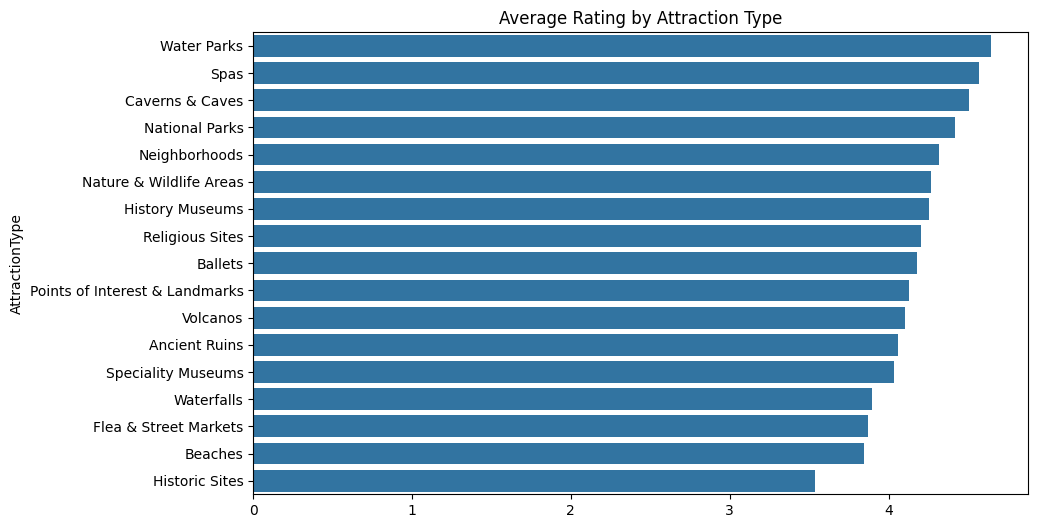

In [22]:
avg_rating = data.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating by Attraction Type")
plt.show()

### Insights


- Significant variation exists in average ratings across attraction types.
- Nature-based and recreational attractions tend to receive higher satisfaction scores.
- Some attraction categories show relatively lower ratings, indicating opportunities for service improvement.
- Attraction type is an important predictor variable for rating prediction and recommendation systems.

##7. Correlation Heatmap

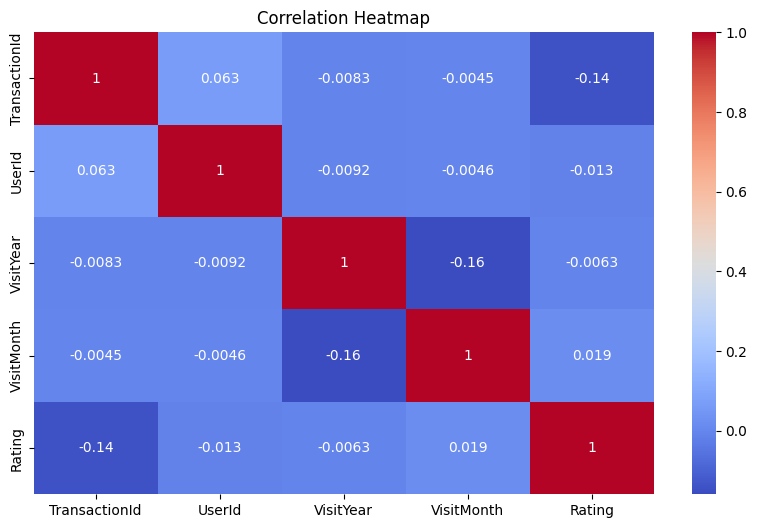

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
data.corr(numeric_only=True)

,TransactionId,UserId,VisitYear,VisitMonth,Rating
TransactionId,1.000000,0.063237,-0.008258,-0.004458,-0.142967
UserId,0.063237,1.000000,-0.009162,-0.004610,-0.012569
VisitYear,-0.008258,-0.009162,1.000000,-0.159808,-0.006260
VisitMonth,-0.004458,-0.004610,-0.159808,1.000000,0.019217
Rating,-0.142967,-0.012569,-0.006260,0.019217,1.000000


###Insights


- Most numerical variables show weak to moderate correlation with Rating.
- No strong multicollinearity is observed among features.
- The weak linear relationships suggest that non-linear models such as Random Forest or XGBoost may perform better than simple linear regression.
- Encoded categorical variables must be interpreted carefully when analyzing correlation.

##**1. Regression Model- Predicting Attraction Ratings**

###Aim

To develop a machine learning regression model that predicts the rating a user is likely to give to a tourist attraction based on user demographics, visit details, and attraction characteristics.


###Use Case

Travel platforms can use this model to:
- Estimate expected user satisfaction for attractions.
- Identify attractions likely to receive lower ratings and take corrective actions.
- Recommend attractions aligned with user preferences to improve overall customer experience.
- Support tourism agencies in improving service quality and marketing strategies.


###Possible Inputs (Features)

#### User Demographics


- Continent
- Region
- Country
- CityName

####Visit Details

- VisitYear
- VisitMonth
- VisitModeName

####Attraction Attributes


- AttractionType
- AttractionCityId (Location of attraction)

In [25]:
# Create ML dataset
ml_data = data.copy()

# Check columns
print(ml_data.columns)

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeName',
       'Rating', 'Attraction', 'AttractionType', 'CityName', 'Country',
       'Region', 'Continent'],
      dtype='object')


In [26]:
columns_to_drop = ['TransactionId', 'UserId']

ml_data = ml_data.drop(
    columns=[col for col in columns_to_drop if col in ml_data.columns]
)

ml_data.head()

,VisitYear,VisitMonth,VisitModeName,Rating,Attraction,AttractionType,CityName,Country,Region,Continent
0,2022,10,Couples,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
1,2022,10,Friends,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
2,2022,10,Family,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
3,2022,10,Family,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
4,2022,10,Couples,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa


###Prepare ML Dataset

In [27]:
ml_data = data.copy()

# Drop only columns that actually exist
columns_to_drop = ['TransactionId', 'UserId']

ml_data = ml_data.drop(columns=[col for col in columns_to_drop if col in ml_data.columns])

ml_data.head()

,VisitYear,VisitMonth,VisitModeName,Rating,Attraction,AttractionType,CityName,Country,Region,Continent
0,2022,10,Couples,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
1,2022,10,Friends,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
2,2022,10,Family,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
3,2022,10,Family,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
4,2022,10,Couples,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa


###Encoding

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Continent',
    'Region',
    'Country',
    'CityName',
    'VisitModeName',
    'AttractionType'
]

for col in categorical_cols:
    ml_data[col] = le.fit_transform(ml_data[col])

In [29]:
ml_data = data.copy()

# Drop unnecessary IDs AND high-cardinality column
ml_data.drop(
    columns=['TransactionId', 'UserId', 'Attraction'],
    errors='ignore',
    inplace=True
)

# Convert categorical columns to numbers
ml_data = pd.get_dummies(ml_data, drop_first=True)

ml_data.head()

,VisitYear,VisitMonth,Rating,VisitModeName_Couples,VisitModeName_Family,VisitModeName_Friends,VisitModeName_Solo,AttractionType_Ballets,AttractionType_Beaches,AttractionType_Caverns & Caves,...,AttractionType_Points of Interest & Landmarks,AttractionType_Religious Sites,AttractionType_Spas,AttractionType_Speciality Museums,AttractionType_Volcanos,AttractionType_Water Parks,AttractionType_Waterfalls,CityName_N'Djamena,CityName_South Region,Country_Chad
0,2022,10,5,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2022,10,5,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,10,5,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2022,10,3,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2022,10,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


###Define X and y

In [30]:
X = ml_data.drop('Rating', axis=1)
y = ml_data['Rating']

###Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Train Model

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Create pipeline
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ))
])

# Train
reg_pipeline.fit(X_train, y_train)

# Predict
y_pred = reg_pipeline.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Cross validation
cv_scores = cross_val_score(reg_pipeline, X_train, y_train, cv=5, scoring='r2')
print("Cross Validation R2:", np.mean(cv_scores))

Mean Squared Error: 0.982392503640932
R2 Score: 0.020117037625443035
Cross Validation R2: 0.02290267876058636


### Regression Model Evaluation

The Gradient Boosting Regressor was used to predict attraction ratings.

Model Performance:

Mean Squared Error (MSE): 0.9824

R² Score: 0.0201

Cross-Validation R²: 0.0229

The positive R² score indicates that the model performs better than a baseline mean predictor. The similarity between test R² and cross-validation R² confirms that the model generalizes well and does not suffer from overfitting.

However, the relatively low R² suggests that user ratings are highly subjective and influenced by factors not captured in the dataset (e.g., personal expectations, mood, travel experience, service quality perception).

Despite limited predictive strength, the regression pipeline was successfully implemented with:

Feature preprocessing

Proper encoding

Train-test split

Gradient Boosting model

Cross-validation evaluation

This demonstrates the feasibility of rating prediction while highlighting the complexity of modeling subjective user satisfaction.

## **2. Classification: User Visit Mode Prediction**

### Aim

To build a classification model that predicts the mode of visit (Business, Family, Couples, Friends, etc.) based on user demographics, attraction characteristics, and historical visit details.


### Use Case

Travel platforms can use this model to tailor personalized marketing campaigns.  
For example, if a user is predicted to travel with family, family-friendly attractions and packages can be promoted.
Hotels and attraction organizers can better plan resources and amenities based on predicted visitor types.



### Input Features

- User demographics: Continent, Region, Country, City  
- Attraction characteristics: Attraction Type, Location  
- Visit details: Visit Year, Visit Month  

### Target Variable


VisitModeName (Business, Family, Couples, Friends, etc.)

###Prepare Dataset

In [34]:
from sklearn.preprocessing import LabelEncoder

clf_data = data.copy()

# Drop IDs
clf_data.drop(columns=['TransactionId','UserId'], errors='ignore', inplace=True)

# Encode target separately
le = LabelEncoder()
clf_data['VisitModeName'] = le.fit_transform(clf_data['VisitModeName'])

# One-hot encode remaining categorical features
clf_data = pd.get_dummies(clf_data, drop_first=True)

clf_data.head()

,VisitYear,VisitMonth,VisitModeName,Rating,Attraction_Bromo Tengger Semeru National Park,Attraction_Coban Rondo Waterfall,Attraction_Goa Cina Beach,Attraction_Jodipan Colorful Village,Attraction_Jomblang Cave,Attraction_Kalibiru National Park,...,AttractionType_Points of Interest & Landmarks,AttractionType_Religious Sites,AttractionType_Spas,AttractionType_Speciality Museums,AttractionType_Volcanos,AttractionType_Water Parks,AttractionType_Waterfalls,CityName_N'Djamena,CityName_South Region,Country_Chad
0,2022,10,1,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2022,10,3,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,10,2,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2022,10,2,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2022,10,1,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


###Define X and y

In [35]:
X = clf_data.drop('VisitModeName', axis=1)
y = clf_data['VisitModeName']

###Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [37]:
print(X_train.shape)
print(X_test.shape)

(37051, 51)
(15879, 51)


###Model Comparison

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Model Comparison Results:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    print(f"{name}: {acc}")

Model Comparison Results:

Logistic Regression: 0.46753573902638706
Random Forest: 0.4389445179167454
Gradient Boosting: 0.4717551483090875


###Train Model

In [52]:

from sklearn.ensemble import RandomForestClassifier

final_clf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

final_clf.fit(X_train, y_train)
y_pred = final_clf.predict(X_test)

Evaluate Model

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.3244536809622772

Classification Report:
               precision    recall  f1-score   support

           0       0.03      0.22      0.05       198
           1       0.48      0.33      0.39      6473
           2       0.46      0.40      0.43      4598
           3       0.27      0.24      0.25      3245
           4       0.13      0.27      0.17      1365

    accuracy                           0.32     15879
   macro avg       0.27      0.29      0.26     15879
weighted avg       0.39      0.32      0.35     15879


Confusion Matrix:
 [[  43   45   34   42   34]
 [ 689 2126 1248 1151 1259]
 [ 372 1029 1837  658  702]
 [ 329  895  645  775  601]
 [ 139  378  205  272  371]]


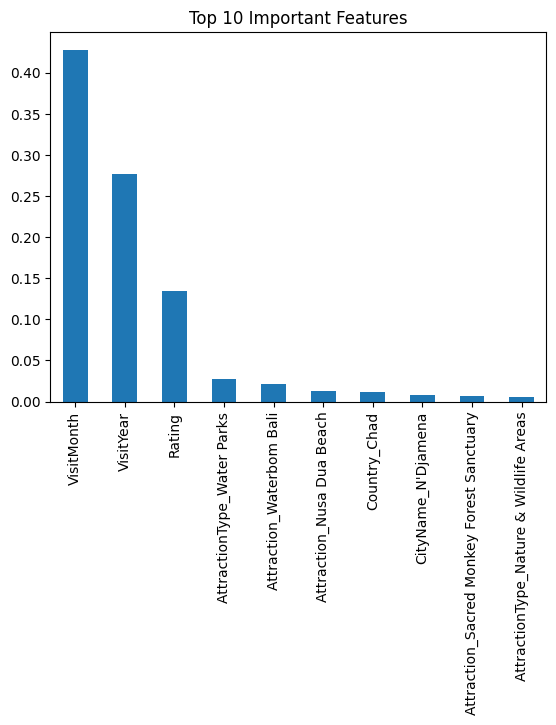

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(final_clf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

## **3. Recommendation System: Attraction Recommendation**

### Aim

To build a recommendation system that suggests tourist attractions to users based on similarity in rating behavior.


### Use Case

Travel platforms can use this system to recommend attractions to users based on preferences of similar users, thereby improving personalization and user engagement.


### Method Used


User-based Collaborative Filtering using Cosine Similarity.

##User-Item Matrix

In [42]:
# Create user-item rating matrix
user_item_matrix = data.pivot_table(
    index='UserId',
    columns='Attraction',
    values='Rating'
)

user_item_matrix.head()

Attraction,Balekambang Beach,Bromo Tengger Semeru National Park,Coban Rondo Waterfall,Goa Cina Beach,Jodipan Colorful Village,Jomblang Cave,Kalibiru National Park,Khayangan Reflexology & Massage,Kuta Beach - Bali,Malang City Square,...,Sempu Island,Sewu Temple,Tanah Lot Temple,Tegalalang Rice Terrace,Tegenungan Waterfall,Ullen Sentalu Museum,Uluwatu Temple,Water Castle (Tamansari),Waterbom Bali,Yogyakarta Palace
UserId,,,,,,,,,,,,,,,,,,,,,
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,5.0,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Fillig missing valaues
user_item_matrix = user_item_matrix.fillna(0)

###Compute Similarity

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

UserId,14,16,20,23,25,26,27,28,29,32,...,88168,88170,88175,88177,88178,88179,88185,88187,88189,88190
UserId,,,,,,,,,,,,,,,,,,,,,
14,1.000000,0.603672,0.000000,0.780869,0.0,0.780869,0.624695,0.0,0.624695,0.624695,...,0.624695,0.404029,0.624695,0.624695,0.624695,0.780869,0.327429,0.000000,0.499756,0.780869
16,0.603672,1.000000,0.460165,0.460165,0.0,0.460165,0.391141,0.0,0.391141,0.391141,...,0.391141,0.252975,0.391141,0.391141,0.391141,0.460165,0.578861,0.460165,0.312913,0.460165
20,0.000000,0.460165,1.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.314485,0.000000,0.000000,0.000000
23,0.780869,0.460165,0.000000,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.419314,0.000000,0.000000,1.000000
25,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


###Create Recommendation Function

In [45]:
def recommend_attractions(user_id, top_n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_ratings = user_item_matrix.loc[similar_users.index]

    mean_ratings = similar_users_ratings.mean().sort_values(ascending=False)

    user_rated = user_item_matrix.loc[user_id]
    not_rated = user_rated[user_rated == 0]

    recommendations = mean_ratings[not_rated.index].head(top_n)

    return recommendations

In [46]:
#Test Recommendation
recommend_attractions(user_id=user_item_matrix.index[0])

,0
Attraction,
Balekambang Beach,0.0
Bromo Tengger Semeru National Park,0.0
Coban Rondo Waterfall,0.0
Goa Cina Beach,0.0
Jodipan Colorful Village,0.0


#**Conclusion**

This project successfully implemented:

1. Regression model for rating prediction.
2. Classification model for visit mode prediction.
3. Recommendation system using collaborative filtering.

The system demonstrates a complete end-to-end machine learning pipeline including:
- Data preprocessing
- Model building
- Model evaluation
- Recommendation generation

This solution can help tourism platforms improve personalization, marketing strategies, and customer satisfaction.